## Preamble

In [1]:
# dependencies.
import sys
import ast
import logging
from pathlib import Path

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, mean_poisson_deviance,
    r2_score, mean_squared_error
)


# initialize logger.
log = logging.getLogger(__name__)
log.addHandler(logging.StreamHandler(stream=sys.stdout))
log.setLevel(logging.INFO)

log.info("Log initialized.")

# set seed.
RANDOM_SEED = 4890
np.random.seed(RANDOM_SEED)

# directories.
DATA_DIR = Path("../_data").resolve()
OUTPUT_DIR = Path("../output").resolve()

# load training data.
df_train = pd.read_csv(DATA_DIR / "train.csv")

df_train['claim_sev'] = df_train.apply(
    lambda row: row['claimcst0'] / row['numclaims'] if row['numclaims'] != 0 else np.nan,
    axis=1
)

cat_cols = [
    'veh_body', 'area', 'engine_type'
]

# 3. Numerical columns = everything except categorical + target
num_cols = ["max_power", "credit_score", "veh_age"]
features = num_cols + cat_cols

for col in cat_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    
# split by sample.
train = df_train[df_train["sample"] == "1|bld"].copy()
validate = df_train[df_train["sample"] == "2|val"].copy()

# 5. Create feature and target matrices
X_train = train[num_cols + cat_cols]
y_train = train["claimcst0"]

X_val = validate[num_cols + cat_cols]
y_val = validate["claimcst0"]

Log initialized.


## XGBoost

### Utils

In [2]:
def log_reg_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                    label: str = "", freq_model: bool = False) -> None:
    """Logs regression metrics."""
    
    log.info(f"\n{'='*80}")
    log.info(f"Regression Results: {label}")
    log.info(f"{'-'*80}")
    
    log.info(f"N: {len(y_true)}")
    log.info(f"RMSE: {root_mean_squared_error(y_true=y_true, y_pred=y_pred)}")
    log.info(f"MSE: {mean_squared_error(y_true=y_true, y_pred=y_pred)}")
    log.info(f"MAE: {mean_absolute_error(y_true=y_true, y_pred=y_pred)}")
    log.info(f"R2: {r2_score(y_true=y_true, y_pred=y_pred)}")
    
    non_zero = y_true != 0
    if non_zero.sum() > 0:
        mape = np.mean(np.abs(
            (y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero]
        )) * 100
        log.info(f"MAPE: {mape}%")
    else:
        log.info("MAPE: N/A")
        
    if freq_model:
        y_pred_pos = np.maximum(y_pred, 1e-10)
        poisson_dev = mean_poisson_deviance(y_true=y_true, y_pred=y_pred_pos)
        print(f"Poisson Deviance: {poisson_dev}")
    
    print(f"Mean Actual: {y_true.mean()}")
    print(f"Mean Predicted: {y_pred.mean()}")
    
    log.info(f"{'='*80}\n")
    
    return None

### Frequency Model

In [3]:
# splits/arrays.
x_train_freq = train[features].copy()
y_train_freq = train["numclaims"].copy()
x_validate_freq = validate[features].copy()
y_validate_freq = validate["numclaims"].copy()

# create model.
xgb_reg = xgb.XGBRegressor(
    objective="count:poisson",
    eval_metric="poisson-nloglik",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="auto"
)

param_freq = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 6, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [50, 100, 150],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1.0, 2.0, 5.0],
    "gamma": [0, 0.1, 0.2]
}

freq_hyper = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_freq,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
freq_hyper.fit(X=x_train_freq, y=y_train_freq)

log.info(f"\n\nBest hyper-parameters: {freq_hyper.best_params_}")

# validation metrics & featrue import.
freq_model: xgb.XGBRegressor = freq_hyper.best_estimator_   # type: ignore

y_freq_pred_train = freq_model.predict(x_train_freq)
log_reg_metrics(
    y_true=np.array(y_train_freq.values), 
    y_pred=y_freq_pred_train, 
    label="Frequency Model - Training Set",
    freq_model=True
)

y_freq_pred_validate = freq_model.predict(x_validate_freq)
log_reg_metrics(
    y_true=np.array(y_validate_freq.values), 
    y_pred=y_freq_pred_validate,
    label="Frequency Model - Validation Set",
    freq_model=True
)

freq_importance = pd.DataFrame({
    "feature": features,
    "importance": freq_model.feature_importances_
})
freq_importance = freq_importance.sort_values("importance", ascending=False)
log.info(
    "\nTop 10 Feature Importance (Frequency model):\n"
    f"{freq_importance.head(10)}"
)

# export.
freq_model.save_model(OUTPUT_DIR / "xgboost_freq_model.json")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best hyper-parameters: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 50, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

Regression Results: Frequency Model - Training Set
--------------------------------------------------------------------------------
N: 11204
RMSE: 0.27016681432724
MSE: 0.07299011200666428
MAE: 0.13343928754329681
R2: 0.006535768508911133
MAPE: 92.6607157884474%
Poisson Deviance: 0.3813609182834625
Mean Actual: 0.07184933952159943
Mean Predicted: 0.07190601527690887


Regression Results: Frequency Model - Validation Set
--------------------------------------------------------------------------------
N: 3796
RMSE: 0.27154961228370667
MSE: 0.0737391859292984
MAE: 0.1329539716243744
R2: 0.0031398534774780273
MAPE: 92.87600533781098%
Poisson Deviance: 0.38378915190696716
Mean Actual: 0.07112750263435196
Mean Predicted: 0.0716960653

---

### Severity Model

In [4]:
# Only want positive claims.
train_sev = train.dropna(subset=["claim_sev"]).copy()
validate_sev = validate.dropna(subset=["claim_sev"]).copy()

# splits/arrays.
x_train_sev = train_sev[features].copy()
y_train_sev = train_sev["claim_sev"].copy()
x_validate_sev = validate_sev[features].copy()
y_validate_sev = validate_sev["claim_sev"].copy()

# create model.
xgb_sev = xgb.XGBRegressor(
    objective="reg:gamma",
    eval_metric="gamma-nloglik",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="auto"
)

param_sev = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.05, 0.1, 0.5],
    "reg_lambda": [1.0, 2.0, 5.0],
    "gamma": [0, 0.1, 0.2, 0.5]
}

sev_hyper = RandomizedSearchCV(
    estimator=xgb_sev,
    param_distributions=param_sev,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

sev_hyper.fit(X=x_train_sev, y=y_train_sev)

log.info(f"\n\nBest hyper-parameters: {sev_hyper.best_params_}")

# validation metrics & feature import.
sev_model: xgb.XGBRegressor = sev_hyper.best_estimator_ # type: ignore

y_sev_pred_train = sev_model.predict(x_train_sev)
log_reg_metrics(
    y_true=y_train_sev.values, 
    y_pred=y_sev_pred_train, 
    label="Severity Model - Training Set"
)

y_sev_pred_validate = sev_model.predict(x_validate_sev)
log_reg_metrics(
    y_true=y_validate_sev.values, 
    y_pred=y_sev_pred_validate, 
    label="Severity Model - Validation Set"
)

sev_importance = pd.DataFrame({
    "feature": features,
    "importance": sev_model.feature_importances_
})
sev_importance = sev_importance.sort_values("importance", ascending=False)

log.info(
    "\nTop 10 Feature Importance (Severity model):\n"
    f"{sev_importance.head(10)}"  # ✅ Fixed variable name
)

# export.
sev_model.save_model(OUTPUT_DIR / "xgboost_sev_model.json")
df_train


Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best hyper-parameters: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.05, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}

Regression Results: Severity Model - Training Set
--------------------------------------------------------------------------------
N: 767
RMSE: 4681.063206298305
MSE: 21912352.741359767
MAE: 3293.389525628544
R2: 0.20142433291276374
MAPE: 64.92787088398167%
Mean Actual: 6561.753229076271
Mean Predicted: 6106.2998046875


Regression Results: Severity Model - Validation Set
--------------------------------------------------------------------------------
N: 255
RMSE: 5932.045081418077
MSE: 35189158.847976394
MAE: 4207.106668659314
R2: -0.0420276855604782
MAPE: 77.8942176497386%
Mean Actual: 7044.301619217647
Mean Predicted: 6052.2197265625


Top 10 Feature Importance (Severity model):
        feature  importance
1  credit_scor

,id,fold,sample,veh_value,exposure,veh_body,veh_age,gender,area,agecat,...,e_bill,time_of_week_driven,time_driven,trm_len,credit_score,low_education_ind,clm,numclaims,claimcst0,claim_sev
0,1,2,1|bld,5.80,0.362191,10,2,F,1,1,...,0,weekday,12pm - 6pm,6,646.516469,0.0,1,1,2023.198184,2023.198184
1,2,3,1|bld,5.67,0.632068,9,4,F,0,2,...,0,weekend,6am - 12pm,12,635.400369,0.0,1,1,3600.172234,3600.172234
2,3,1,1|bld,5.90,0.367460,8,2,F,2,2,...,0,weekday,6am - 12pm,12,646.463131,0.0,1,1,2021.144067,2021.144067
3,4,2,1|bld,4.79,0.802184,9,3,M,1,4,...,1,weekday,6pm - 12am,12,645.598794,0.0,1,1,4006.845492,4006.845492
4,5,2,1|bld,6.68,0.485009,8,3,M,2,1,...,0,weekday,6am - 12pm,12,657.348612,0.0,1,1,2542.953931,2542.953931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,3,1|bld,6.00,0.512586,9,4,F,4,5,...,1,weekday,12pm - 6pm,12,646.700941,0.0,0,0,0.000000,NaN
14996,14997,3,1|bld,5.50,0.620050,8,1,M,4,5,...,0,weekday,6am - 12pm,12,653.533358,0.0,0,0,0.000000,NaN
14997,14998,1,1|bld,6.11,0.519530,12,4,M,5,3,...,0,weekday,12pm - 6pm,12,643.704163,0.0,0,0,0.000000,NaN
14998,14999,1,1|bld,5.65,0.385664,10,1,M,2,4,...,0,weekday,6am - 12pm,12,692.281511,0.0,0,0,0.000000,NaN


### Combined Model

In [5]:

# predict on full dataset.
freq_pred_train_full = freq_model.predict(x_train_freq)
freq_pred_validate_full = freq_model.predict(x_validate_freq)

sev_pred_train_full = sev_model.predict(x_train_freq)
sev_pred_validate_full = sev_model.predict(x_validate_freq)

# calc. expected loss = frequency × severity
expected_loss_train = freq_pred_train_full * sev_pred_train_full
expected_loss_validate = freq_pred_validate_full * sev_pred_validate_full

# actual total claim cost.
actual_loss_train = np.array(train["claimcst0"].values)
actual_loss_validate = np.array(validate["claimcst0"].values)

# metrics.
combined_metrics_train = log_reg_metrics(
    y_true=actual_loss_train, 
    y_pred=expected_loss_train, 
    label="Combined Model - Training Set"
)

combined_metrics_val = log_reg_metrics(
    y_true=actual_loss_validate, 
    y_pred=expected_loss_validate, 
    label="Combined Model - Validation Set"
)

# calc. premium
prem_actual_val = np.array(actual_loss_validate)
prem_pred_val = np.array(expected_loss_validate)

log.info(f"\n{'='*80}")
log.info("Premium Statistics:")
log.info(f"{'-'*80}")
log.info(f"Actual Mean: ${round(prem_actual_val.mean(), 2)}")
log.info(f"Predicted Mean: ${round(prem_pred_val.mean(), 2)}")
log.info(f"Acutal Median: ${np.median(prem_actual_val)}")
log.info(f"Predicted Median: ${np.median(prem_pred_val)}")
log.info(f"{'='*80}\n")


Regression Results: Combined Model - Training Set
--------------------------------------------------------------------------------
N: 11204
RMSE: 2258.071788358779
MSE: 5098888.201381814
MAE: 843.3343152263716
R2: 0.01105565167089495
MAPE: 89.74498868502054%
Mean Actual: 471.82733843243483
Mean Predicted: 434.6788635253906


Regression Results: Combined Model - Validation Set
--------------------------------------------------------------------------------
N: 3796
RMSE: 2378.0031553045274
MSE: 5654899.006638288
MAE: 863.9540537162742
R2: 0.0009087220112857786
MAPE: 89.72784227374227%
Mean Actual: 492.0542510289779
Mean Predicted: 431.7055969238281


Premium Statistics:
--------------------------------------------------------------------------------
Actual Mean: $492.05
Predicted Mean: $431.7099914550781
Acutal Median: $0.0
Predicted Median: $422.8226318359375



In [6]:
# over v under priced.
freq_full = freq_model.predict(df_train[features])
sev_full = sev_model.predict(df_train[features])
combined_full = freq_full * sev_full

df_train["predicted"] = combined_full
df_train["pred_diff"] = df_train["predicted"] - (df_train["claim_sev"] * df_train["numclaims"])

overunder = df_train.copy()[abs(df_train["pred_diff"]) > 100]

## Inference

In [7]:
test_clean = pd.read_csv(DATA_DIR / "test.csv")

cat_cols = [
    'veh_body', 'area', 'engine_type'
]

# 3. Numerical columns = everything except categorical + target
num_cols = ["max_power", "credit_score", "veh_age"]

for col in cat_cols:
    le = LabelEncoder()
    test_clean[col] = le.fit_transform(test_clean[col])

# Drop only fold/sample (id is needed later)
test_clean = test_clean.drop(columns=["fold", "sample"], errors='ignore')

# Reorder columns to match training
X_test = test_clean.copy()[features]

# Predict using final model
test_pred_freq = freq_model.predict(X_test)
test_pred_sev = sev_model.predict(X_test)
test_prem = test_pred_freq * test_pred_sev

# Create output DataFrame
output = test_clean.copy()
output["predicted_clm"] = test_pred_freq
output["predicted_sev"] = test_pred_sev
output["predicted_premium"] = test_prem

# Save result
output.to_csv("../output/xgboost_predictions_inference.csv", index=False)

output.sort_values(by=["predicted_premium"]).head(10)

,id,veh_value,exposure,veh_body,veh_age,gender,area,agecat,engine_type,max_power,...,marital_status,e_bill,time_of_week_driven,time_driven,trm_len,credit_score,low_education_ind,predicted_clm,predicted_sev,predicted_premium
9108,11457,6.37,0.141090,8,2,M,1,1,0,79,...,M,0,weekend,6am - 12pm,6,646.121178,0,0.066787,3875.744873,258.850616
6600,1038,6.25,0.300442,8,2,M,1,3,1,86,...,S,1,weekday,6am - 12pm,12,646.858134,0,0.065944,3975.416260,262.153992
4146,6068,6.16,0.175824,8,2,M,1,4,3,90,...,M,0,weekend,6pm - 12am,12,658.770188,0,0.062866,4182.243164,262.920380
13835,3285,5.96,0.560566,8,1,M,1,3,0,92,...,S,0,weekday,12pm - 6pm,12,645.858416,0,0.065289,4070.160156,265.736938
683,4852,5.93,0.046329,8,2,M,0,4,0,93,...,S,0,weekday,12pm - 6pm,12,646.923485,0,0.068052,3906.653076,265.857056
10636,12691,4.88,0.923865,6,2,F,1,2,0,91,...,M,1,weekday,12pm - 6pm,12,661.259230,1,0.063006,4235.931152,266.888550
888,6675,6.33,0.471493,8,2,M,1,4,0,78,...,M,0,weekday,12pm - 6pm,12,644.483752,0,0.065910,4099.462402,270.196564
196,2405,5.22,0.111646,6,2,F,1,1,0,73,...,M,1,weekend,12am - 6 am,6,646.812941,0,0.066272,4084.157959,270.666931
12472,6250,6.74,0.375644,8,3,M,1,4,0,92,...,S,1,weekday,12pm - 6pm,12,653.272120,0,0.064763,4222.544434,273.463959
14459,8540,6.24,0.208243,6,3,F,1,1,0,92,...,M,1,weekday,6am - 12pm,12,660.600340,0,0.063750,4297.654785,273.973846


## SHAP

/Users/fogellmcmuffin/anaconda3/envs/datathon/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_16718/2828189775.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_validate_sev, plot_type="bar")


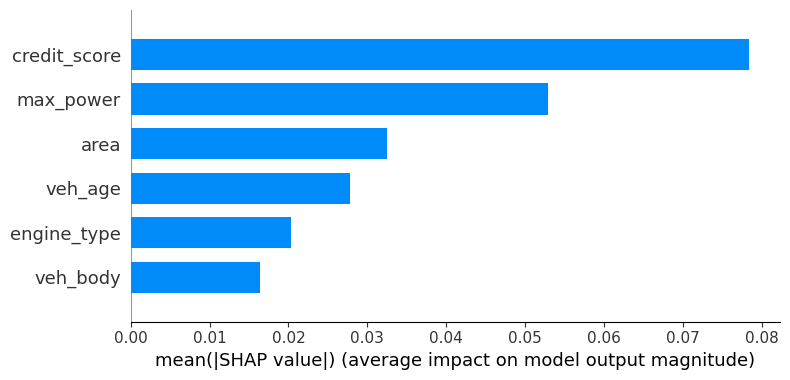

/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_16718/2828189775.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_validate_sev)


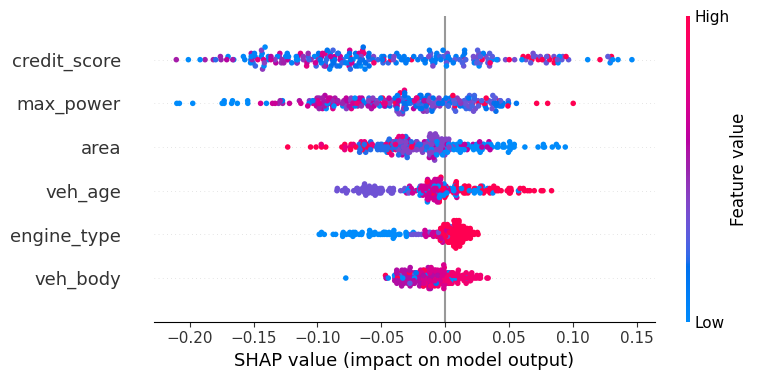

In [8]:
import shap

# SHAP expects a small sample for speed
explainer = shap.TreeExplainer(sev_model)

# Use a subset of validation set to compute SHAP values
shap_values = explainer.shap_values(x_validate_sev)

# Global Variable Importance
shap.summary_plot(shap_values, x_validate_sev, plot_type="bar")

# SHAP Summary Plot (beeswarm)
shap.summary_plot(shap_values, x_validate_sev)

## Figures

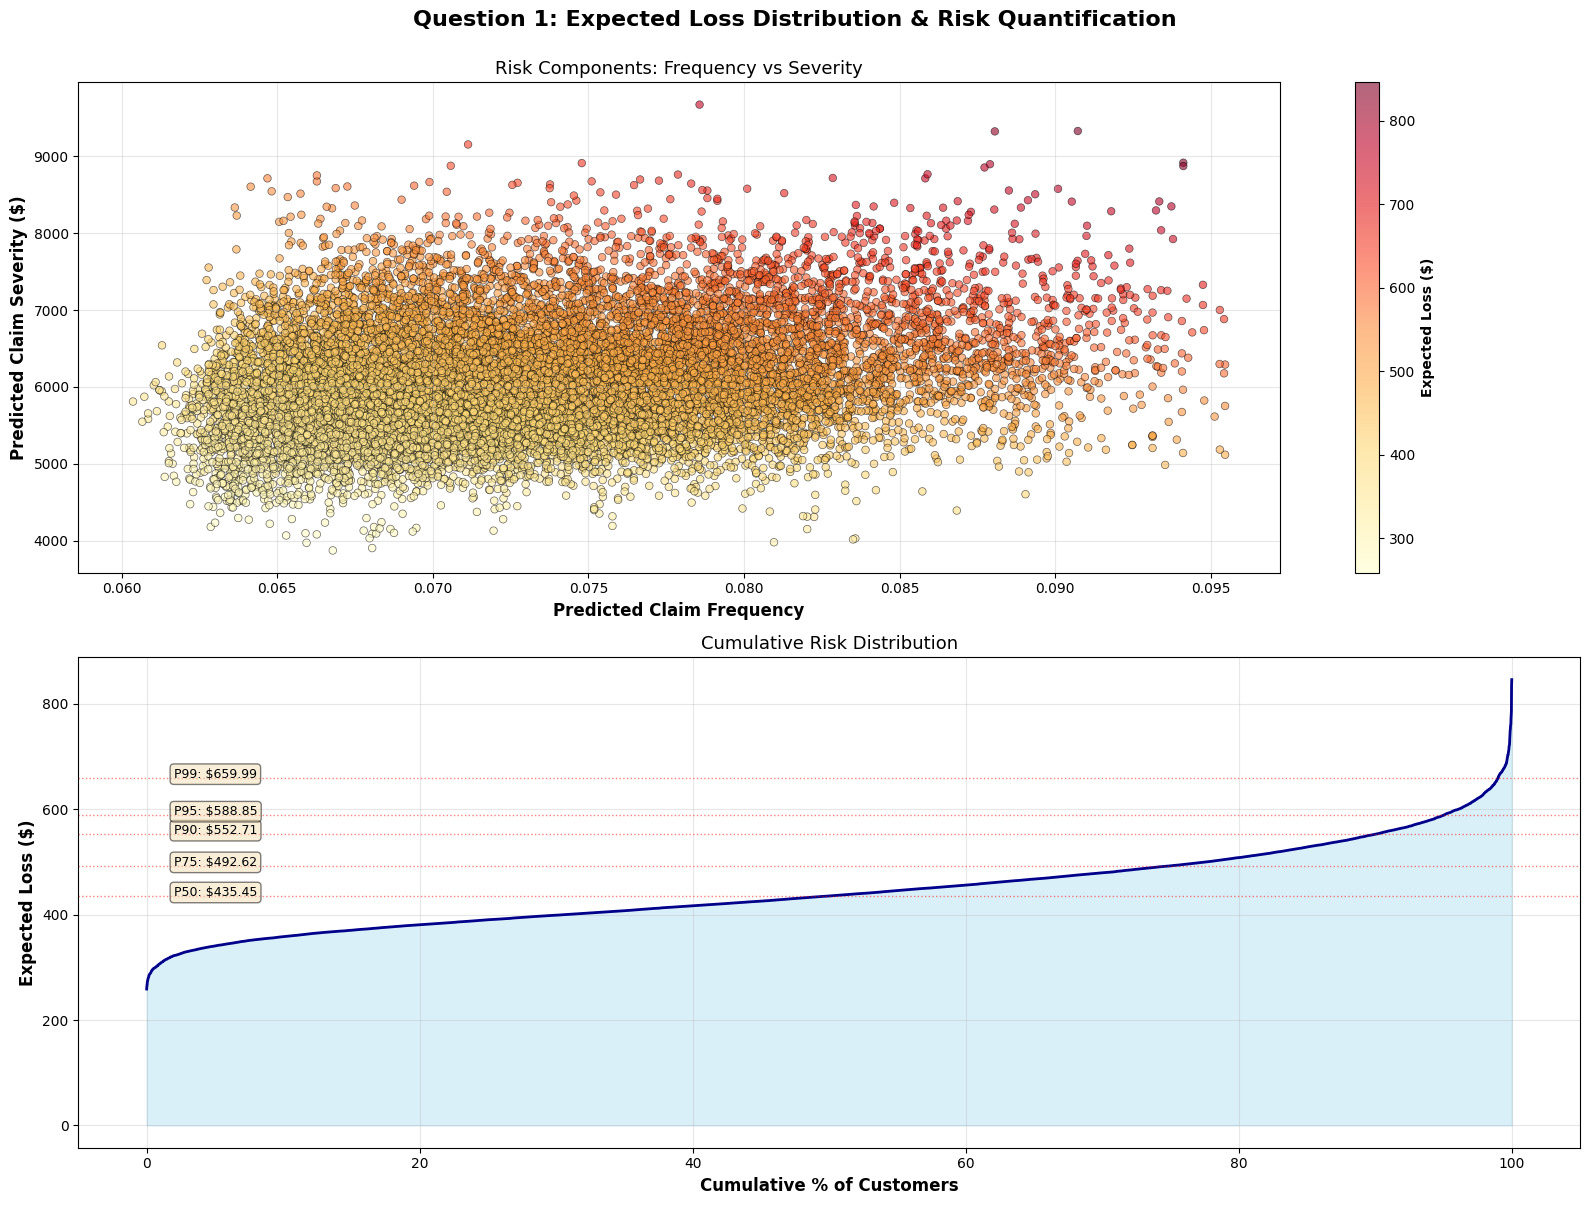

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Question 1: Expected Loss Distribution & Risk Quantification', 
                fontsize=16, fontweight='bold', y=1.00)

ax3 = axes[0]
scatter = ax3.scatter(output['predicted_clm'], output['predicted_sev'], 
                        c=output['predicted_premium'], cmap='YlOrRd', 
                        alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Predicted Claim Frequency', fontsize=12, fontweight='bold')
ax3.set_ylabel('Predicted Claim Severity ($)', fontsize=12, fontweight='bold')
ax3.set_title('Risk Components: Frequency vs Severity', fontsize=13)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Expected Loss ($)', fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = axes[1]
sorted_premium = np.sort(output['predicted_premium'])
cumulative_pct = np.arange(1, len(sorted_premium) + 1) / len(sorted_premium) * 100
ax4.plot(cumulative_pct, sorted_premium, color='darkblue', linewidth=2)
ax4.fill_between(cumulative_pct, sorted_premium, alpha=0.3, color='skyblue')

percentiles = [50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(output['predicted_premium'], p)
    ax4.axhline(val, color='red', linestyle=':', alpha=0.5, linewidth=1)
    ax4.text(2, val, f'P{p}: ${val:.2f}', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax4.set_xlabel('Cumulative % of Customers', fontsize=12, fontweight='bold')
ax4.set_ylabel('Expected Loss ($)', fontsize=12, fontweight='bold')
ax4.set_title('Cumulative Risk Distribution', fontsize=13)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/risk_quantification.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_16718/1222028800.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_500['profile'] = top_500['marital_status'].astype(str) + '-' + top_500['gender'].astype(str)
/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_16718/1222028800.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


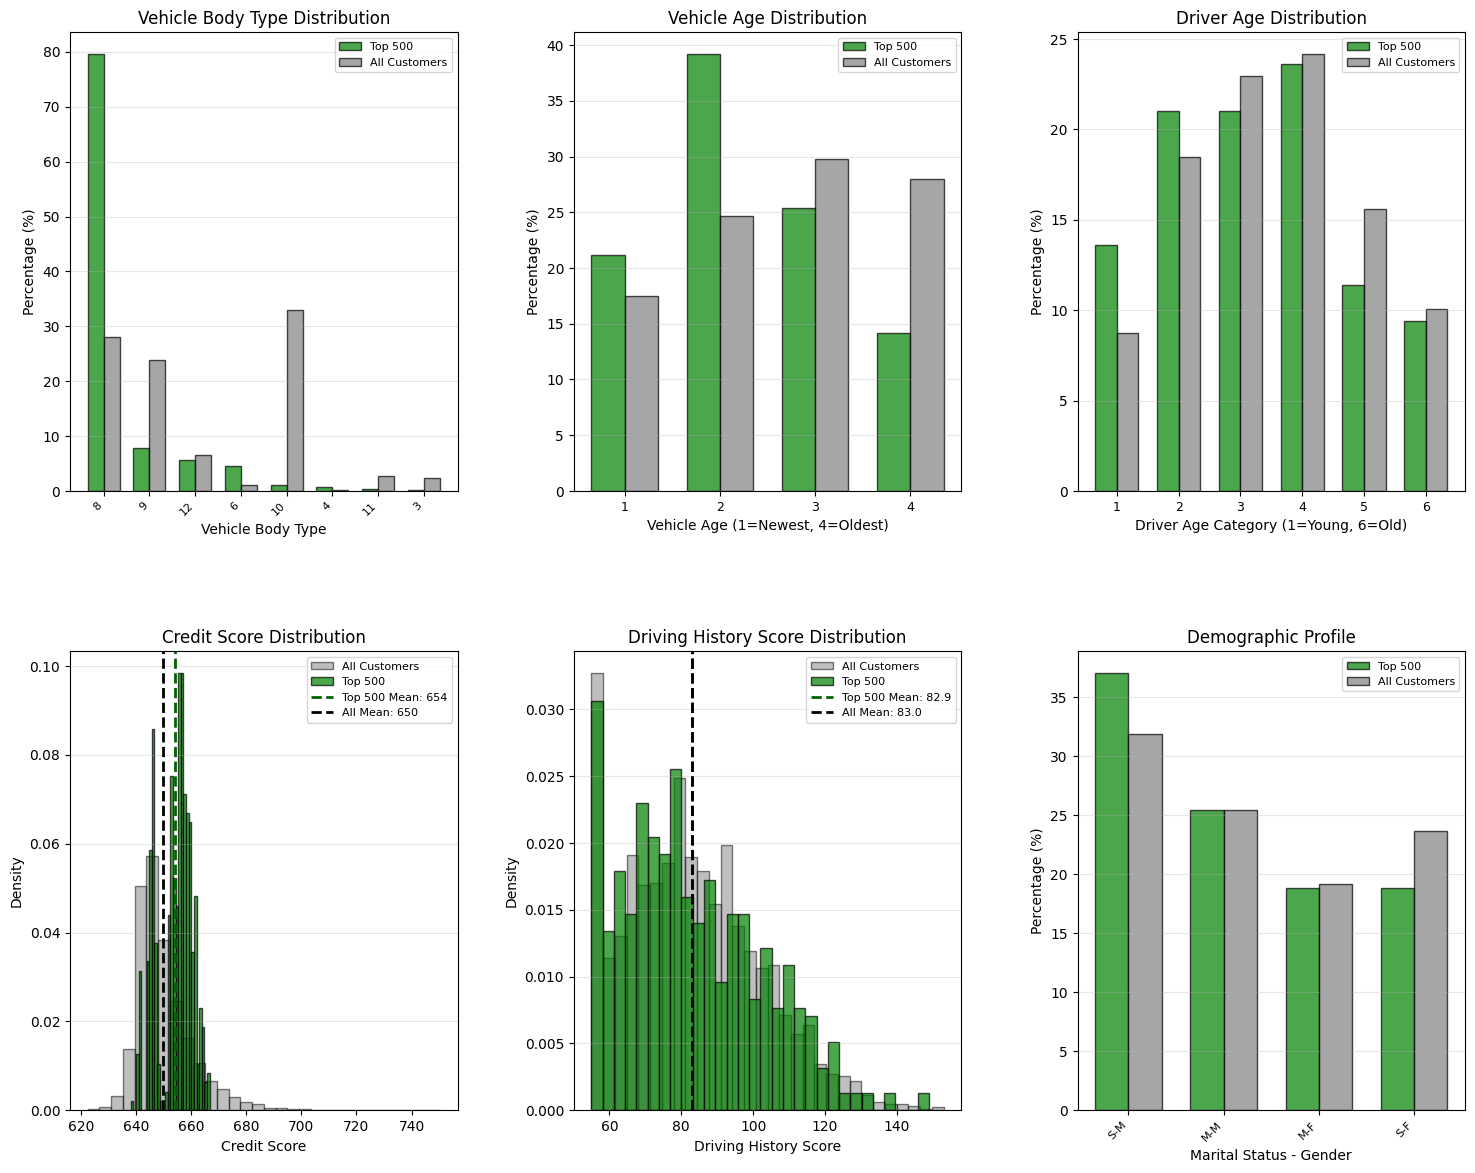

In [10]:
output_sorted = output.sort_values(by='predicted_premium').reset_index(drop=True)

top_100 = output_sorted.head(100)
top_500 = output_sorted.head(500)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

ax3 = fig.add_subplot(gs[0, 0])
if 'veh_body' in top_500.columns:
    body_counts = top_500['veh_body'].value_counts()
    all_body_pct = output['veh_body'].value_counts(normalize=True) * 100
    top_body_pct = body_counts / len(top_500) * 100
    
    x = np.arange(len(body_counts))
    width = 0.35
    bars1 = ax3.bar(x - width/2, top_body_pct.values, width, label='Top 500', 
                    color='green', alpha=0.7, edgecolor='black')
    bars2 = ax3.bar(x + width/2, [all_body_pct.get(idx, 0) for idx in body_counts.index], 
                    width, label='All Customers', color='gray', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Vehicle Body Type', fontsize=10)
    ax3.set_ylabel('Percentage (%)', fontsize=10)
    ax3.set_title('Vehicle Body Type Distribution')
    ax3.set_xticks(x)
    ax3.set_xticklabels(body_counts.index, fontsize=8, rotation=45, ha='right')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')

ax4 = fig.add_subplot(gs[0, 1])
if 'veh_age' in top_500.columns:
    age_counts = top_500['veh_age'].value_counts().sort_index()
    all_age_pct = output['veh_age'].value_counts(normalize=True).sort_index() * 100
    top_age_pct = age_counts / len(top_500) * 100
    
    x = np.arange(len(age_counts))
    width = 0.35
    ax4.bar(x - width/2, top_age_pct.values, width, label='Top 500', 
            color='green', alpha=0.7, edgecolor='black')
    ax4.bar(x + width/2, all_age_pct.values, width, label='All Customers', 
            color='gray', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Vehicle Age (1=Newest, 4=Oldest)', fontsize=10)
    ax4.set_ylabel('Percentage (%)', fontsize=10)
    ax4.set_title('Vehicle Age Distribution')
    ax4.set_xticks(x)
    ax4.set_xticklabels(age_counts.index, fontsize=9)
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3, axis='y')

ax5 = fig.add_subplot(gs[0, 2])
if 'agecat' in top_500.columns:
    agecat_counts = top_500['agecat'].value_counts().sort_index()
    all_agecat_pct = output['agecat'].value_counts(normalize=True).sort_index() * 100
    top_agecat_pct = agecat_counts / len(top_500) * 100
    
    x = np.arange(len(agecat_counts))
    width = 0.35
    ax5.bar(x - width/2, top_agecat_pct.values, width, label='Top 500', 
            color='green', alpha=0.7, edgecolor='black')
    ax5.bar(x + width/2, all_agecat_pct.values, width, label='All Customers', 
            color='gray', alpha=0.7, edgecolor='black')
    ax5.set_xlabel('Driver Age Category (1=Young, 6=Old)', fontsize=10)
    ax5.set_ylabel('Percentage (%)', fontsize=10)
    ax5.set_title('Driver Age Distribution')
    ax5.set_xticks(x)
    ax5.set_xticklabels(agecat_counts.index, fontsize=9)
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3, axis='y')

ax6 = fig.add_subplot(gs[1, 0])
if 'credit_score' in top_500.columns:
    ax6.hist(output['credit_score'], bins=30, alpha=0.5, 
             label='All Customers', color='gray', edgecolor='black', density=True)
    ax6.hist(top_500['credit_score'], bins=30, alpha=0.7, 
             label='Top 500', color='green', edgecolor='black', density=True)
    ax6.axvline(top_500['credit_score'].mean(), color='darkgreen', 
                linestyle='--', linewidth=2, label=f'Top 500 Mean: {top_500["credit_score"].mean():.0f}')
    ax6.axvline(output['credit_score'].mean(), color='black', 
                linestyle='--', linewidth=2, label=f'All Mean: {output["credit_score"].mean():.0f}')
    ax6.set_xlabel('Credit Score', fontsize=10)
    ax6.set_ylabel('Density', fontsize=10)
    ax6.set_title('Credit Score Distribution')
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3, axis='y')

ax7 = fig.add_subplot(gs[1, 1])
if 'driving_history_score' in top_500.columns:
    ax7.hist(output['driving_history_score'], bins=30, alpha=0.5, 
             label='All Customers', color='gray', edgecolor='black', density=True)
    ax7.hist(top_500['driving_history_score'], bins=30, alpha=0.7, 
             label='Top 500', color='green', edgecolor='black', density=True)
    ax7.axvline(top_500['driving_history_score'].mean(), color='darkgreen', 
                linestyle='--', linewidth=2, label=f'Top 500 Mean: {top_500["driving_history_score"].mean():.1f}')
    ax7.axvline(output['driving_history_score'].mean(), color='black', 
                linestyle='--', linewidth=2, label=f'All Mean: {output["driving_history_score"].mean():.1f}')
    ax7.set_xlabel('Driving History Score', fontsize=10)
    ax7.set_ylabel('Density', fontsize=10)
    ax7.set_title('Driving History Score Distribution')
    ax7.legend(fontsize=8)
    ax7.grid(True, alpha=0.3, axis='y')

ax8 = fig.add_subplot(gs[1, 2])
if 'marital_status' in top_500.columns and 'gender' in top_500.columns:
    top_500['profile'] = top_500['marital_status'].astype(str) + '-' + top_500['gender'].astype(str)
    output['profile'] = output['marital_status'].astype(str) + '-' + output['gender'].astype(str)
    
    profile_counts = top_500['profile'].value_counts()
    all_profile_pct = output['profile'].value_counts(normalize=True) * 100
    top_profile_pct = profile_counts / len(top_500) * 100
    
    x = np.arange(len(profile_counts))
    width = 0.35
    ax8.bar(x - width/2, top_profile_pct.values, width, label='Top 500', 
            color='green', alpha=0.7, edgecolor='black')
    ax8.bar(x + width/2, [all_profile_pct.get(idx, 0) for idx in profile_counts.index], 
            width, label='All Customers', color='gray', alpha=0.7, edgecolor='black')
    ax8.set_xlabel('Marital Status - Gender', fontsize=10)
    ax8.set_ylabel('Percentage (%)', fontsize=10)
    ax8.set_title('Demographic Profile')
    ax8.set_xticks(x)
    ax8.set_xticklabels(profile_counts.index, fontsize=8, rotation=45, ha='right')
    ax8.legend(fontsize=8)
    ax8.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/potential_customers.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_16718/713097850.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(segments.values(), labels=segments.keys(),
/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_16718/713097850.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


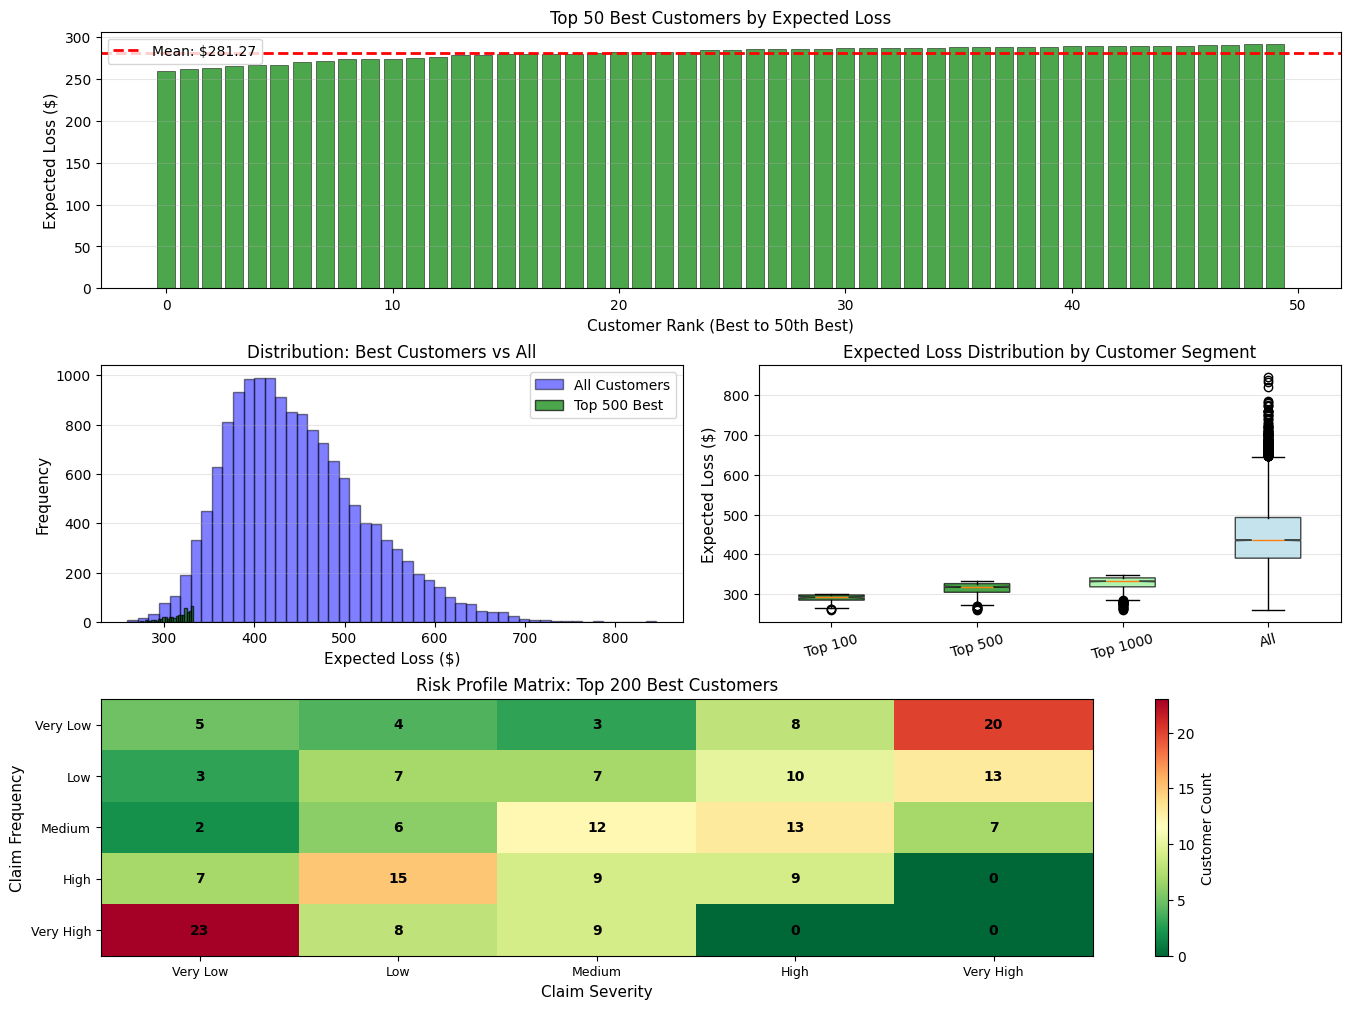

In [11]:
output_sorted = output.sort_values(by='predicted_premium').reset_index(drop=True)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0:])
top_50 = output_sorted.head(50)
x_pos = np.arange(len(top_50))
bars = ax1.bar(x_pos, top_50['predicted_premium'], 
               color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Customer Rank (Best to 50th Best)', fontsize=11)
ax1.set_ylabel('Expected Loss ($)', fontsize=11)
ax1.set_title('Top 50 Best Customers by Expected Loss')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(top_50['predicted_premium'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: ${top_50["predicted_premium"].mean():.2f}')
ax1.legend()

top_100 = output_sorted.head(100)
top_500 = output_sorted.head(500)

ax3 = fig.add_subplot(gs[1, 0:2])
ax3.hist(output['predicted_premium'], bins=50, alpha=0.5, 
         label='All Customers', color='blue', edgecolor='black')
ax3.hist(top_500['predicted_premium'], bins=30, alpha=0.7, 
         label='Top 500 Best', color='green', edgecolor='black')
ax3.set_xlabel('Expected Loss ($)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution: Best Customers vs All')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

ax6 = fig.add_subplot(gs[1, 2:4])
segments = {
    'Top 100': output_sorted.head(100)['predicted_premium'],
    'Top 500': output_sorted.head(500)['predicted_premium'],
    'Top 1000': output_sorted.head(1000)['predicted_premium'],
    'All': output_sorted['predicted_premium']
}
bp = ax6.boxplot(segments.values(), labels=segments.keys(),
                  patch_artist=True, notch=True)
colors = ['darkgreen', 'green', 'lightgreen', 'lightblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax6.set_ylabel('Expected Loss ($)', fontsize=11)
ax6.set_title('Expected Loss Distribution by Customer Segment')
ax6.grid(True, alpha=0.3, axis='y')
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=15)

ax7 = fig.add_subplot(gs[2, 0:])
top_200 = output_sorted.head(200)
freq_bins = pd.qcut(top_200['predicted_clm'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
sev_bins = pd.qcut(top_200['predicted_sev'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
risk_matrix = pd.crosstab(freq_bins, sev_bins)
im = ax7.imshow(risk_matrix.values, cmap='RdYlGn_r', aspect='auto')
ax7.set_xticks(np.arange(len(risk_matrix.columns)))
ax7.set_yticks(np.arange(len(risk_matrix.index)))
ax7.set_xticklabels(risk_matrix.columns, fontsize=9)
ax7.set_yticklabels(risk_matrix.index, fontsize=9)
ax7.set_xlabel('Claim Severity', fontsize=11)
ax7.set_ylabel('Claim Frequency', fontsize=11)
ax7.set_title('Risk Profile Matrix: Top 200 Best Customers')
for i in range(len(risk_matrix.index)):
    for j in range(len(risk_matrix.columns)):
        text = ax7.text(j, i, int(risk_matrix.values[i, j]),
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax7, label='Customer Count')

plt.tight_layout()
plt.savefig('../output/pred_expected_loss.png', dpi=300, bbox_inches='tight')
plt.show()

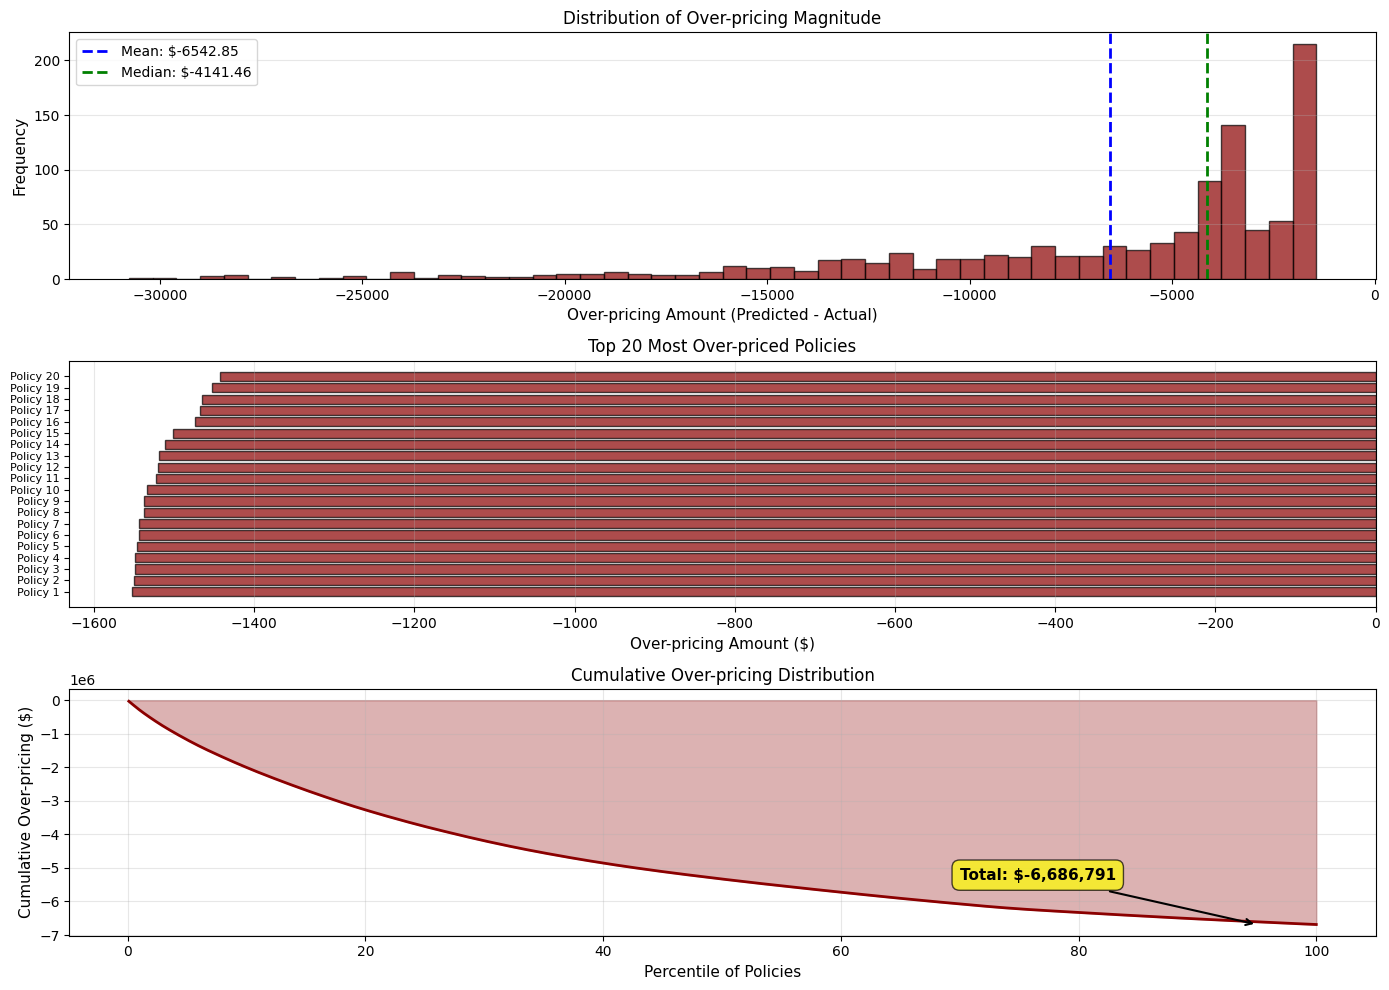

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

ax2 = axes[0]
ax2.hist(overunder['pred_diff'], bins=50, color='darkred', alpha=0.7, edgecolor='black')
ax2.axvline(overunder['pred_diff'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Mean: ${overunder["pred_diff"].mean():.2f}')
ax2.axvline(overunder['pred_diff'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: ${overunder["pred_diff"].median():.2f}')
ax2.set_xlabel('Over-pricing Amount (Predicted - Actual)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Over-pricing Magnitude')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[1]
top_20 = overunder.nlargest(20, 'pred_diff').copy()
top_20 = top_20.sort_values('pred_diff')
y_pos = np.arange(len(top_20))
bars = ax3.barh(y_pos, top_20['pred_diff'], color='darkred', alpha=0.7, edgecolor='black')
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f'Policy {i}' for i in range(1, 21)], fontsize=8)
ax3.set_xlabel('Over-pricing Amount ($)', fontsize=11)
ax3.set_title('Top 20 Most Over-priced Policies')
ax3.grid(True, alpha=0.3, axis='x')

ax4 = axes[2]
sorted_diff = np.sort(overunder['pred_diff'].values)
cumulative = np.cumsum(sorted_diff)
percentiles = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff) * 100
ax4.plot(percentiles, cumulative, color='darkred', linewidth=2)
ax4.fill_between(percentiles, 0, cumulative, alpha=0.3, color='darkred')
ax4.set_xlabel('Percentile of Policies', fontsize=11)
ax4.set_ylabel('Cumulative Over-pricing ($)', fontsize=11)
ax4.set_title('Cumulative Over-pricing Distribution')
ax4.grid(True, alpha=0.3)


total_overpricing = cumulative[-1]
ax4.annotate(f'Total: ${total_overpricing:,.0f}', 
             xy=(95, total_overpricing), xytext=(70, total_overpricing * 0.8),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('../output/expected_loss.png', dpi=300, bbox_inches='tight')
plt.show()